In [20]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [2]:
MODEL_PATH = r"C:\Users\arif.arshad\Desktop\MicroAI\models\mix_2class.keras"

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "preprocess_input": tf.keras.applications.mobilenet_v2.preprocess_input
    },
    safe_mode=False,
    compile=False
)

print("Model loaded successfully!")
model.summary()


Model loaded successfully!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable Float16 weight quantization
converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.target_spec.supported_types = [
    tf.float16
]

# Convert
tflite_float16 = converter.convert()

# Save
FP16_MODEL = "colon_mobilenetv2_float16.tflite"

with open(FP16_MODEL, "wb") as f:
    f.write(tflite_float16)

print("Float16 model saved:", FP16_MODEL)
print(
    "Size:",
    os.path.getsize(FP16_MODEL) / (1024 * 1024),
    "MB"
)

INFO:tensorflow:Assets written to: C:\Users\ARIF~1.ARS\AppData\Local\Temp\tmpqczdkl75\assets


INFO:tensorflow:Assets written to: C:\Users\ARIF~1.ARS\AppData\Local\Temp\tmpqczdkl75\assets


Saved artifact at 'C:\Users\ARIF~1.ARS\AppData\Local\Temp\tmpqczdkl75'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2148635004368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635005136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635004944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635003792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635005328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635006672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635007440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635007248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635007632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2148635006480: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [4]:
interpreter_fp16 = tf.lite.Interpreter(
    model_path="colon_mobilenetv2_float16.tflite"
)

interpreter_fp16.allocate_tensors()

input_details = interpreter_fp16.get_input_details()
output_details = interpreter_fp16.get_output_details()

print("Input:")
print(input_details)

print("\nOutput:")
print(output_details)

Input:
[{'name': 'serving_default_input_layer_4:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 284, 'shape': array([1, 2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


c:\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [13]:
IMAGE_SIZE = 224

# Load image
img = Image.open(r"C:\Users\arif.arshad\Downloads\archive (1)\lung_colon_image_set\Train and Validation Set\colon_aca\colonca1070.jpeg").convert("RGB")
img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

# Convert to numpy
img_array = np.array(img).astype(np.float32)

# Add batch dimension
input_data = np.expand_dims(img_array, axis=0)

# MobileNetV2 preprocessing
input_data = tf.keras.applications.mobilenet_v2.preprocess_input(
    input_data
)

In [14]:
keras_prediction = model.predict(
    input_data,
    verbose=0
)

print("Keras:")
print(keras_prediction)

Keras:
[[0.7496135 0.2623936]]


In [15]:
interpreter_fp16.set_tensor(
    input_details[0]["index"],
    input_data
)

interpreter_fp16.invoke()

fp16_prediction = interpreter_fp16.get_tensor(
    output_details[0]["index"]
)

print("Float16:")
print(fp16_prediction)

Float16:
[[0.73566145 0.27328506]]


In [16]:
difference = np.abs(
    keras_prediction - fp16_prediction
)

print("Absolute difference:")
print(difference)

print(
    "Maximum difference:",
    np.max(difference)
)

Absolute difference:
[[0.01395208 0.01089147]]
Maximum difference: 0.013952076


In [17]:
CLEAN_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_clean"

clean_test_ds = tf.keras.utils.image_dataset_from_directory(
    CLEAN_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(clean_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(clean_test_ds).numpy())

Found 1000 files belonging to 2 classes.
['colon_aca', 'colon_n']
Test batches: 32
['colon_aca', 'colon_n']
Test batches: 32


In [18]:
UGLY_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_ugly"

ugly_test_ds = tf.keras.utils.image_dataset_from_directory(
    UGLY_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(ugly_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(ugly_test_ds).numpy())

Found 1000 files belonging to 2 classes.
['colon_aca', 'colon_n']
Test batches: 32
['colon_aca', 'colon_n']
Test batches: 32


In [19]:
def evaluate_keras(model, dataset):

    y_true = []
    y_pred = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        predicted_labels = np.argmax(
            predictions,
            axis=1
        )

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_labels)

    return np.array(y_true), np.array(y_pred)

In [21]:
def evaluate_float16(interpreter, dataset):

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    y_true = []
    y_pred = []

    for images, labels in dataset:

        images_np = images.numpy().astype(np.float32)

        for i in range(len(images_np)):

            # Add batch dimension
            image = np.expand_dims(
                images_np[i],
                axis=0
            )

            # Run Float16 TFLite model
            interpreter.set_tensor(
                input_details[0]["index"],
                image
            )

            interpreter.invoke()

            predictions = interpreter.get_tensor(
                output_details[0]["index"]
            )

            # Get predicted class
            predicted_label = np.argmax(
                predictions[0]
            )

            y_true.append(
                labels.numpy()[i]
            )

            y_pred.append(
                predicted_label
            )

    return np.array(y_true), np.array(y_pred)

In [28]:
y_true_clean_keras, y_pred_clean_keras = evaluate_keras(
    model,
    clean_test_ds
)

y_true_clean_tflite, y_pred_clean_tflite = evaluate_float16(
    interpreter_fp16,
    clean_test_ds
)

In [29]:
print("===== KERAS =====")

print(
    classification_report(
        y_true_clean_keras,
        y_pred_clean_keras,
        target_names=clean_test_ds.class_names,
        digits=4
    )
)


print("===== FLOAT16 =====")

print(
    classification_report(
        y_true_clean_tflite,
        y_pred_clean_tflite,
        target_names=clean_test_ds.class_names,
        digits=4
    )
)

===== KERAS =====
              precision    recall  f1-score   support

   colon_aca     0.9688    0.9940    0.9812       500
     colon_n     0.9938    0.9680    0.9807       500

    accuracy                         0.9810      1000
   macro avg     0.9813    0.9810    0.9810      1000
weighted avg     0.9813    0.9810    0.9810      1000

===== FLOAT16 =====
              precision    recall  f1-score   support

   colon_aca     0.9688    0.9940    0.9812       500
     colon_n     0.9938    0.9680    0.9807       500

    accuracy                         0.9810      1000
   macro avg     0.9813    0.9810    0.9810      1000
weighted avg     0.9813    0.9810    0.9810      1000



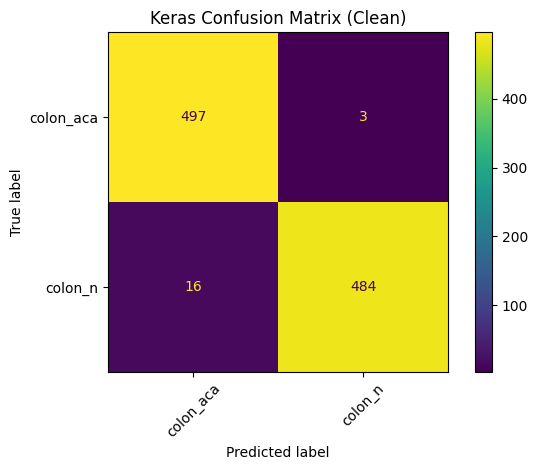

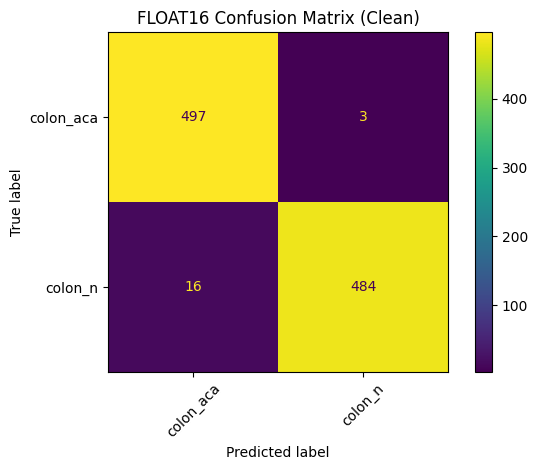

In [30]:
# ============================================================
# 5. CONFUSION MATRICES
# ============================================================

cm_keras = confusion_matrix(
    y_true_clean_keras,
    y_pred_clean_keras
)

cm_tflite = confusion_matrix(
    y_true_clean_tflite,
    y_pred_clean_tflite
)

class_names = clean_test_ds.class_names


# ============================================================
# 6. PLOT KERAS CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_keras,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("Keras Confusion Matrix (Clean)")
plt.tight_layout()
plt.show()


# ============================================================
# 7. PLOT TFLITE CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tflite,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("FLOAT16 Confusion Matrix (Clean)")
plt.tight_layout()
plt.show()

In [26]:
y_true_ugly_keras, y_pred_ugly_keras = evaluate_keras(
    model,
    ugly_test_ds
)

y_true_ugly_tflite, y_pred_ugly_tflite = evaluate_float16(
    interpreter_fp16,
    ugly_test_ds
)

In [31]:
print("===== KERAS =====")

print(
    classification_report(
        y_true_ugly_keras,
        y_pred_ugly_keras,
        target_names=clean_test_ds.class_names,
        digits=4
    )
)


print("===== TFLITE =====")

print(
    classification_report(
        y_true_ugly_tflite,
        y_pred_ugly_tflite,
        target_names=clean_test_ds.class_names,
        digits=4
    )
)

===== KERAS =====
              precision    recall  f1-score   support

   colon_aca     0.9049    0.9700    0.9363       500
     colon_n     0.9677    0.8980    0.9315       500

    accuracy                         0.9340      1000
   macro avg     0.9363    0.9340    0.9339      1000
weighted avg     0.9363    0.9340    0.9339      1000

===== TFLITE =====
              precision    recall  f1-score   support

   colon_aca     0.9064    0.9680    0.9362       500
     colon_n     0.9657    0.9000    0.9317       500

    accuracy                         0.9340      1000
   macro avg     0.9360    0.9340    0.9339      1000
weighted avg     0.9360    0.9340    0.9339      1000



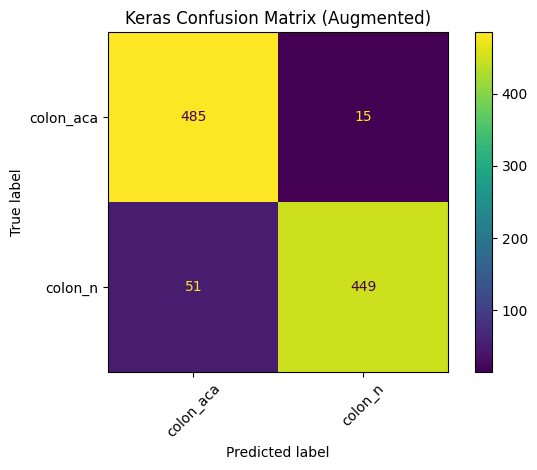

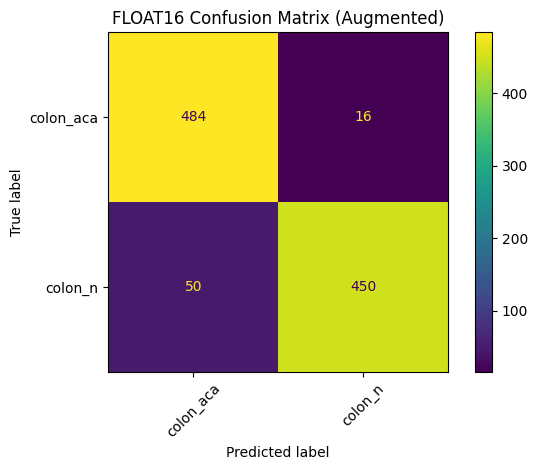

In [32]:
# ============================================================
# 5. CONFUSION MATRICES
# ============================================================

cm_keras = confusion_matrix(
    y_true_ugly_keras,
    y_pred_ugly_keras
)

cm_tflite = confusion_matrix(
    y_true_ugly_tflite,
    y_pred_ugly_tflite
)

class_names = clean_test_ds.class_names


# ============================================================
# 6. PLOT KERAS CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_keras,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("Keras Confusion Matrix (Augmented)")
plt.tight_layout()
plt.show()


# ============================================================
# 7. PLOT TFLITE CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tflite,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("FLOAT16 Confusion Matrix (Augmented)")
plt.tight_layout()
plt.show()